In [1]:
data(mtcars)

In [2]:
model <- glm(vs ~ disp, data = mtcars, family = "binomial")

summary(model)


Call:
glm(formula = vs ~ disp, family = "binomial", data = mtcars)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.8621  -0.4143  -0.0872   0.5694   1.8157  

Coefficients:
             Estimate Std. Error z value Pr(>|z|)   
(Intercept)  4.137827   1.389354   2.978  0.00290 **
disp        -0.021600   0.007131  -3.029  0.00245 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.860  on 31  degrees of freedom
Residual deviance: 22.696  on 30  degrees of freedom
AIC: 26.696

Number of Fisher Scoring iterations: 6


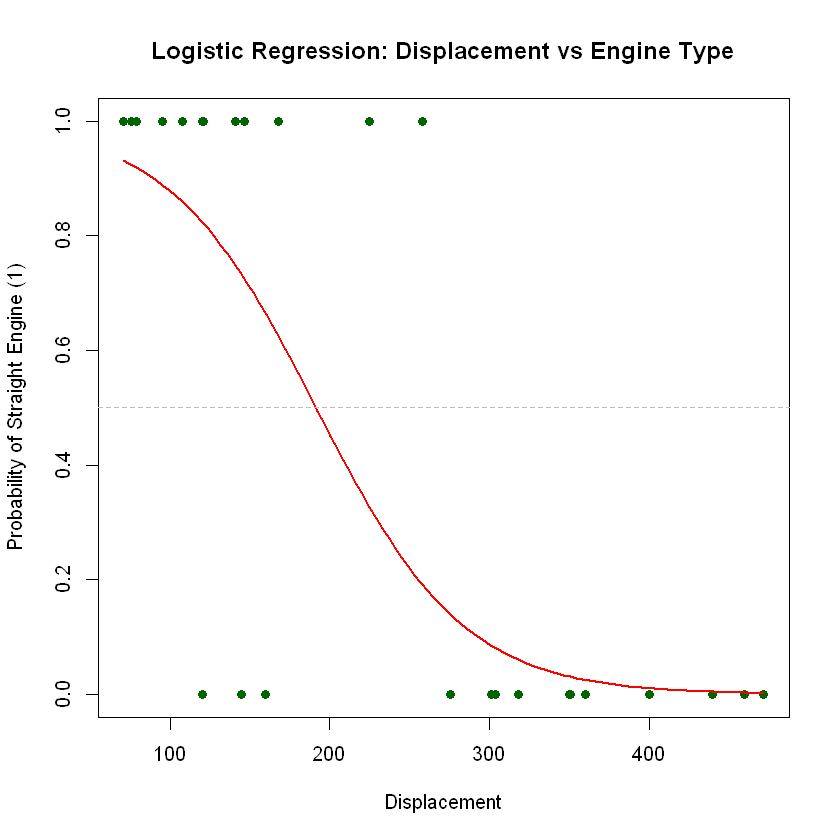

In [3]:
plot(mtcars$disp, mtcars$vs, 
     pch = 16, 
     col = "darkgreen",
     main = "Logistic Regression: Displacement vs Engine Type",
     xlab = "Displacement", 
     ylab = "Probability of Straight Engine (1)")

range_x <- seq(min(mtcars$disp), max(mtcars$disp), length.out = 100)
y_probs <- predict(model, newdata = data.frame(disp = range_x), type = "response")

lines(range_x, y_probs, col = "red", lwd = 2)
abline(h = 0.5, lty = 2, col = "gray")

In [4]:
probs <- predict(model, type = "response")
predictions <- ifelse(probs > 0.5, 1, 0)

conf_matrix <- table(Actual = mtcars$vs, Predicted = predictions)
print("Confusion Matrix:")
print(conf_matrix)

[1] "Confusion Matrix:"
      Predicted
Actual  0  1
     0 14  4
     1  2 12


In [5]:
accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)
print(paste("Accuracy:", round(accuracy, 2)))

[1] "Accuracy: 0.81"
